*Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones - Edición 2025*

*Aprendisaje no Supervisado - Agrupamiento con el dataset de FIFA 2019*



Importacion de Librerias y dataset utilizados

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',1000)
import itertools
import warnings
warnings.filterwarnings("ignore")
import io

In [ ]:
from plotly.offline import init_notebook_mode, plot,iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)
import matplotlib.pyplot as plt
import plotly.tools as tls#visualization
import plotly.figure_factory as ff#visualization
import seaborn as sns

In [ ]:
from sklearn.cluster import KMeans,MeanShift
from sklearn import decomposition

In [ ]:
url = "https://raw.githubusercontent.com/DiploDatos/AprendizajeNOSupervisado/master/2024/2025/male_players.csv"
df_jugadores = pd.read_csv(url)


df_jugadores.shape

(16161, 58)

In [ ]:
df_jugadores.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Rank', 'Name', 'OVR', 'PAC', 'SHO',
       'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint Speed',
       'Positioning', 'Finishing', 'Shot Power', 'Long Shots', 'Volleys',
       'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes'],
      dtype='object')

In [ ]:
df_jugadores.Position.unique()

array(['ST', 'CDM', 'CAM', 'LW', 'CM', 'GK', 'CB', 'RW', 'LB', 'LM', 'RB',
       'RM'], dtype=object)

In [ ]:
df_jugadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16161 entries, 0 to 16160
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0.1           16161 non-null  int64  
 1   Unnamed: 0             16161 non-null  int64  
 2   Rank                   16161 non-null  int64  
 3   Name                   16161 non-null  object 
 4   OVR                    16161 non-null  int64  
 5   PAC                    16161 non-null  int64  
 6   SHO                    16161 non-null  int64  
 7   PAS                    16161 non-null  int64  
 8   DRI                    16161 non-null  int64  
 9   DEF                    16161 non-null  int64  
 10  PHY                    16161 non-null  int64  
 11  Acceleration           16161 non-null  int64  
 12  Sprint Speed           16161 non-null  int64  
 13  Positioning            16161 non-null  int64  
 14  Finishing              16161 non-null  int64  
 15  Sh

In [ ]:
df_jugadores.describe()

,Unnamed: 0.1,Unnamed: 0,Rank,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Weak foot,Skill moves,Age,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
count,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,1816.000000,1816.000000,1816.000000,1816.000000,1816.000000
mean,8080.000000,8080.000000,8934.139657,66.172390,68.149558,54.146835,58.434874,63.599158,50.591981,65.241755,64.778727,64.812264,50.983293,46.680218,58.000990,46.934719,42.579543,47.614813,54.865107,49.554916,42.770621,59.507766,54.207165,48.118743,56.346946,63.664687,64.103088,62.223934,59.039787,58.299672,47.333271,51.868696,47.018873,48.879587,46.635542,66.173442,63.426892,65.317121,56.342986,2.952045,2.393292,25.790545,65.282489,63.281388,62.361784,63.645925,66.120595
std,4665.423186,4665.423186,5003.925857,6.761979,10.612153,13.740389,9.660646,9.262399,16.323879,9.509657,15.478648,15.258747,19.903044,19.912475,12.876878,19.479070,17.707794,15.710242,13.370436,17.922018,16.956133,14.183703,14.424724,18.084827,18.810193,15.097148,14.640849,8.757220,16.712129,12.155230,20.746819,17.371728,20.408949,20.979117,20.509403,11.755204,16.450390,12.370667,16.771384,0.677057,0.783739,4.662681,7.351546,7.019344,7.403049,8.026517,7.775521
min,0.000000,0.000000,1.000000,47.000000,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000,15.000000,15.000000,3.000000,3.000000,20.000000,5.000000,5.000000,10.000000,15.000000,8.000000,6.000000,13.000000,11.000000,7.000000,5.000000,19.000000,20.000000,30.000000,10.000000,15.000000,6.000000,6.000000,5.000000,9.000000,8.000000,27.000000,15.000000,26.000000,11.000000,1.000000,1.000000,17.000000,45.000000,45.000000,44.000000,41.000000,45.000000
25%,4040.000000,4040.000000,5037.000000,62.000000,62.000000,45.000000,52.000000,58.000000,36.000000,59.000000,57.000000,57.000000,40.000000,31.000000,48.000000,32.000000,30.000000,38.000000,46.000000,39.000000,31.000000,55.000000,46.000000,36.000000,51.000000,55.000000,56.000000,57.000000,55.000000,51.000000,27.000000,44.000000,30.000000,29.000000,27.000000,58.000000,57.000000,58.000000,46.000000,3.000000,2.000000,22.000000,60.000000,58.000000,57.000000,58.000000,61.000000
50%,8080.000000,8080.000000,9009.000000,66.000000,69.000000,57.000000,59.000000,64.000000,55.000000,66.000000,68.000000,68.000000,57.000000,51.000000,59.000000,51.000000,44.000000,49.000000,57.000000,54.000000,42.000000,63.000000,57.000000,50.000000,62.000000,66.000000,66.000000,62.000000,63.000000,60.000000,55.000000,55.000000,53.000000,57.000000,54.000000,68.000000,67.000000,66.000000,60.000000,3.000000,2.000000,25.000000,65.000000,63.000000,62.000000,64.000000,66.000000
75%,12120.000000,12120.000000,13135.000000,70.000000,75.000000,64.000000,65.000000,70.000000,64.000000,72.000000,75.000000,75.000000,65.000000,63.000000,68.000000,62.000000,56.000000,59.000000,65.000000,63.000000,55.000000,68.000000,64.000000,62.000000,68.000000,75.000000,74.000000,68.000000,69.000000,66.000000,64.000000,64.000000,64.000000,66.000000,63.000000,75.000000,74.000000,74.000000,69.000000,3.000000,3.000000,29.000000,70.000000,68.000000,67.000000,69.000000,71.000000
max,16160.000000,16160.000000,17717.000000,91.000000,97.000000,93.000000,94.00

Todo jugador debería tener desarrollado las habilidades generales sin importar la posición en el campo de juego, por este motivo se analizarán las distribuciones, outliers, estadísticos de las mismas:

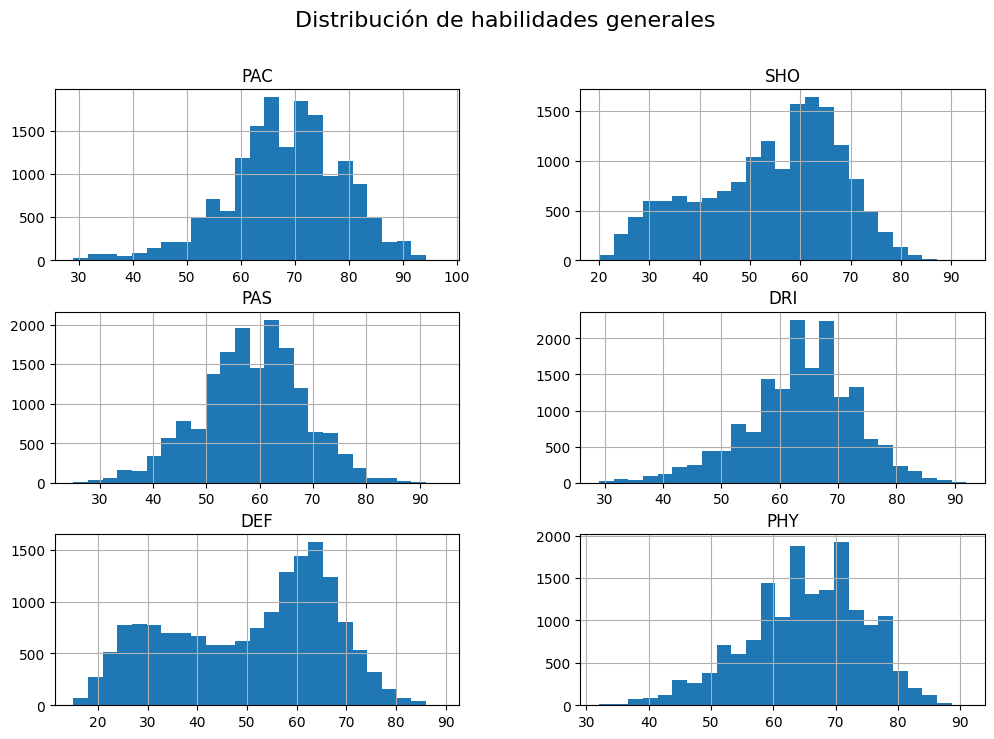

In [ ]:
df_jugadores[['PAC','SHO','PAS','DRI','DEF','PHY']].hist(bins=25, figsize=(12,8))
plt.suptitle("Distribución de habilidades generales", fontsize=16)
plt.show()

Text(0.5, 1.0, 'Boxplot Physical')

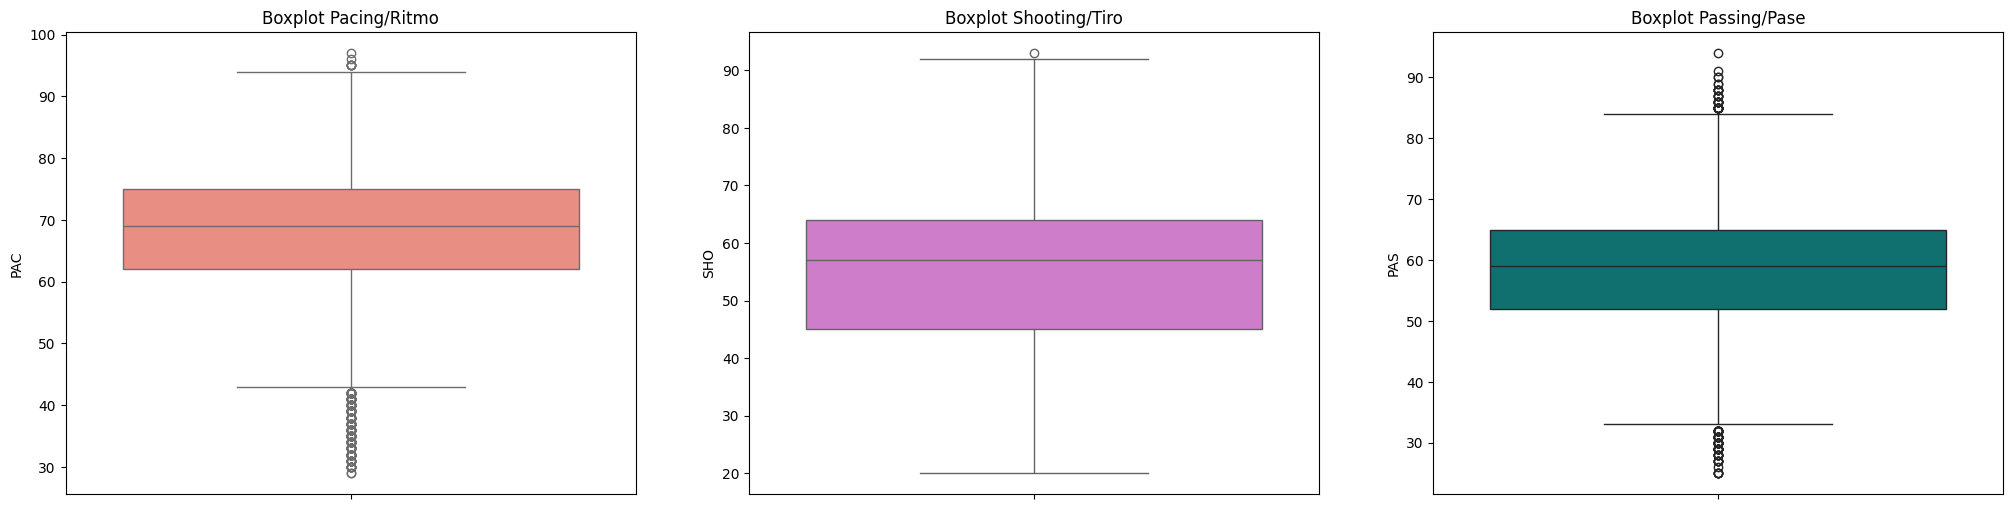

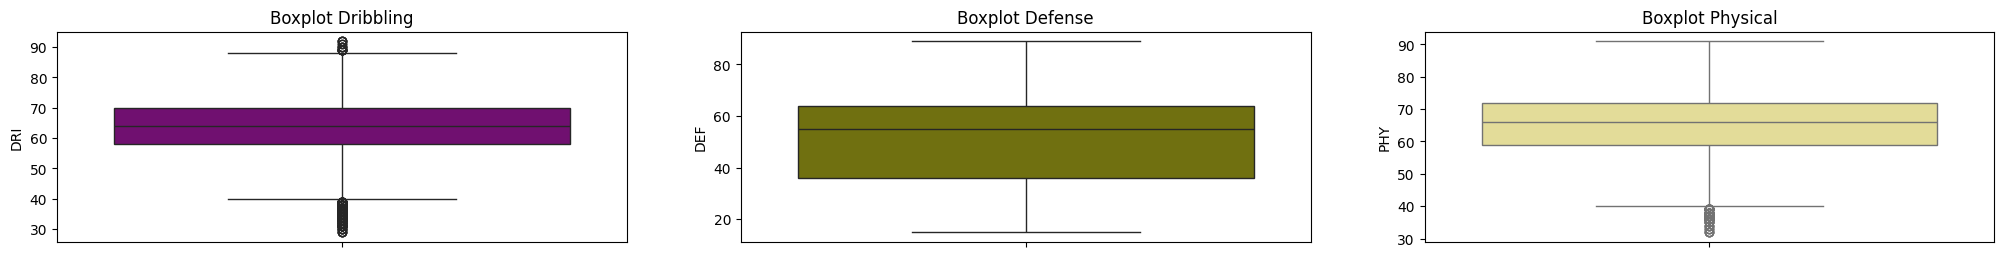

In [ ]:
plt.figure(figsize = (25,6))
plt.subplot(1,3,1)

sns.boxplot(data = df_jugadores,  y = 'PAC', color= 'salmon')
plt.title('Boxplot Pacing/Ritmo')

plt.subplot(1,3,2)
sns.boxplot(data = df_jugadores,  y = 'SHO', color= 'orchid')
plt.title('Boxplot Shooting/Tiro')

plt.subplot(1,3,3)
sns.boxplot(data = df_jugadores,  y = 'PAS', color= 'teal')
plt.title('Boxplot Passing/Pase')

plt.figure(figsize = (25,6))
plt.subplot(2,3,1)
sns.boxplot(data = df_jugadores,  y = 'DRI', color= 'purple')
plt.title('Boxplot Dribbling')

plt.subplot(2,3,2)
sns.boxplot(data = df_jugadores,  y = 'DEF', color= 'olive')
plt.title('Boxplot Defense')

plt.subplot(2,3,3)
sns.boxplot(data = df_jugadores,  y = 'PHY', color= 'khaki')
plt.title('Boxplot Physical')

In [ ]:
df_jugadores[['PAC','SHO','PAS','DRI','DEF','PHY']].describe()

,PAC,SHO,PAS,DRI,DEF,PHY
count,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000,16161.000000
mean,68.149558,54.146835,58.434874,63.599158,50.591981,65.241755
std,10.612153,13.740389,9.660646,9.262399,16.323879,9.509657
min,29.000000,20.000000,25.000000,29.000000,15.000000,32.000000
25%,62.000000,45.000000,52.000000,58.000000,36.000000,59.000000
50%,69.000000,57.000000,59.000000,64.000000,55.000000,66.000000
75%,75.000000,64.000000,65.000000,70.000000,64.000000,72.000000
max,97.000000,93.000000,94.000000,92.000000,89.000000,91.000000


**Análisis de variables de habilidades generales:**

Pacing/Ritmo:
* Es una variable levemente asimétrica, sesgada hacia la derecha, la media es de 68 y la mediana es de 69, es decir que el 50% de los jugadores tiene un estadístico de 69 o menos estando bastante centrada. El 75% de los jugadores tiene un estadístico de 75 o menos. Muy pocos estan por encima de 75, es decir que muy pocos jugadores son rápidos.

Shooting/Tiro:
* Variable bastante asimétrica, sesgada hacia la izquierda. Con media en 54 y mediana en 57, lo que nos indica que la mitad de los jugadores tiene 57 en tiro o menos. El 75% de los jugadores tiene 64 o menos y muy pocos jugadores tienen valores altos, esto se puede deber a que existan menos jugadores habilidosos con buen tiro o que se deba a la posición en la que juega, como por ejemplo delanteros o meidocampistas, que tienen valores altos en esta estadística.

Passing/Pase:
* Variable con distribución más simétrica con una media de 58. La mediana es de 59, indicaconos que la mitad de los jugadores no tiene gran habilidad en pases, el 75% esta por debajo o igual a 65. Muy pocos jugadores tienen un pase excelente o por encima de 65. Muy pocos con pases en 94.

Dribbling:
* Variable con una distribución asimétrica hacia la derecha. Su media es de 63. El 75% de los jugadores tiene un dribbling igual o menor a 70. En cuanto a los valores de dribbling por encima de 70, son pocos los jugadores que tienen esta habilidad más desarrollada y solo 4 jugadores de élite se destacan alcanzando 92 en dribbling.

Defense:
* Variable con distribución bimodal. Con media en 51.6. La mediana esta en 55, es decir que la mitad de los jugadores tiene defensa 55 o menos. El 25% de los jugadores tiene 36 en defensa, casi nula esta habilidad y esto se puede deber a que se trata de delanteros. Son muy pocos jugadores por encima del 75% que tienen valores mayores al 63 alcanzando un máximo de 89, esto puede indicarnos que se trate de defensores o laterales que tienen más marcada o desarrollada la defensa.

Physical/Físico (medida que combina la fuerza, resistencia y capacidad de salto del jugador):
* Variable asimétrica sesgada hacia la derecha, con una media de 65.4. El 75% de los jugadores tiene 72 o menos en esta medida.


Como se puede ver en el análisis de estadísticos, son muy pocos los jugadores con valores altos en cada una de las métricas, esto se debe a que cada jugador tiene una posición o rol en el campo de juego que requiere ciertas capacidades por sobre otras. Cabe destacar tambien, son muy pocos los jugadores con valores altos en todas las habilidades.

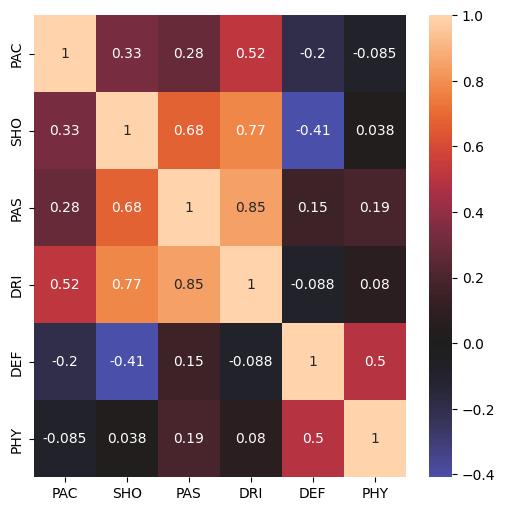

In [ ]:
fig = plt.figure(figsize=(6,6));
sns.heatmap(df_jugadores[['PAC','SHO','PAS','DRI','DEF','PHY']].corr(), annot=True, center=0)
plt.show()

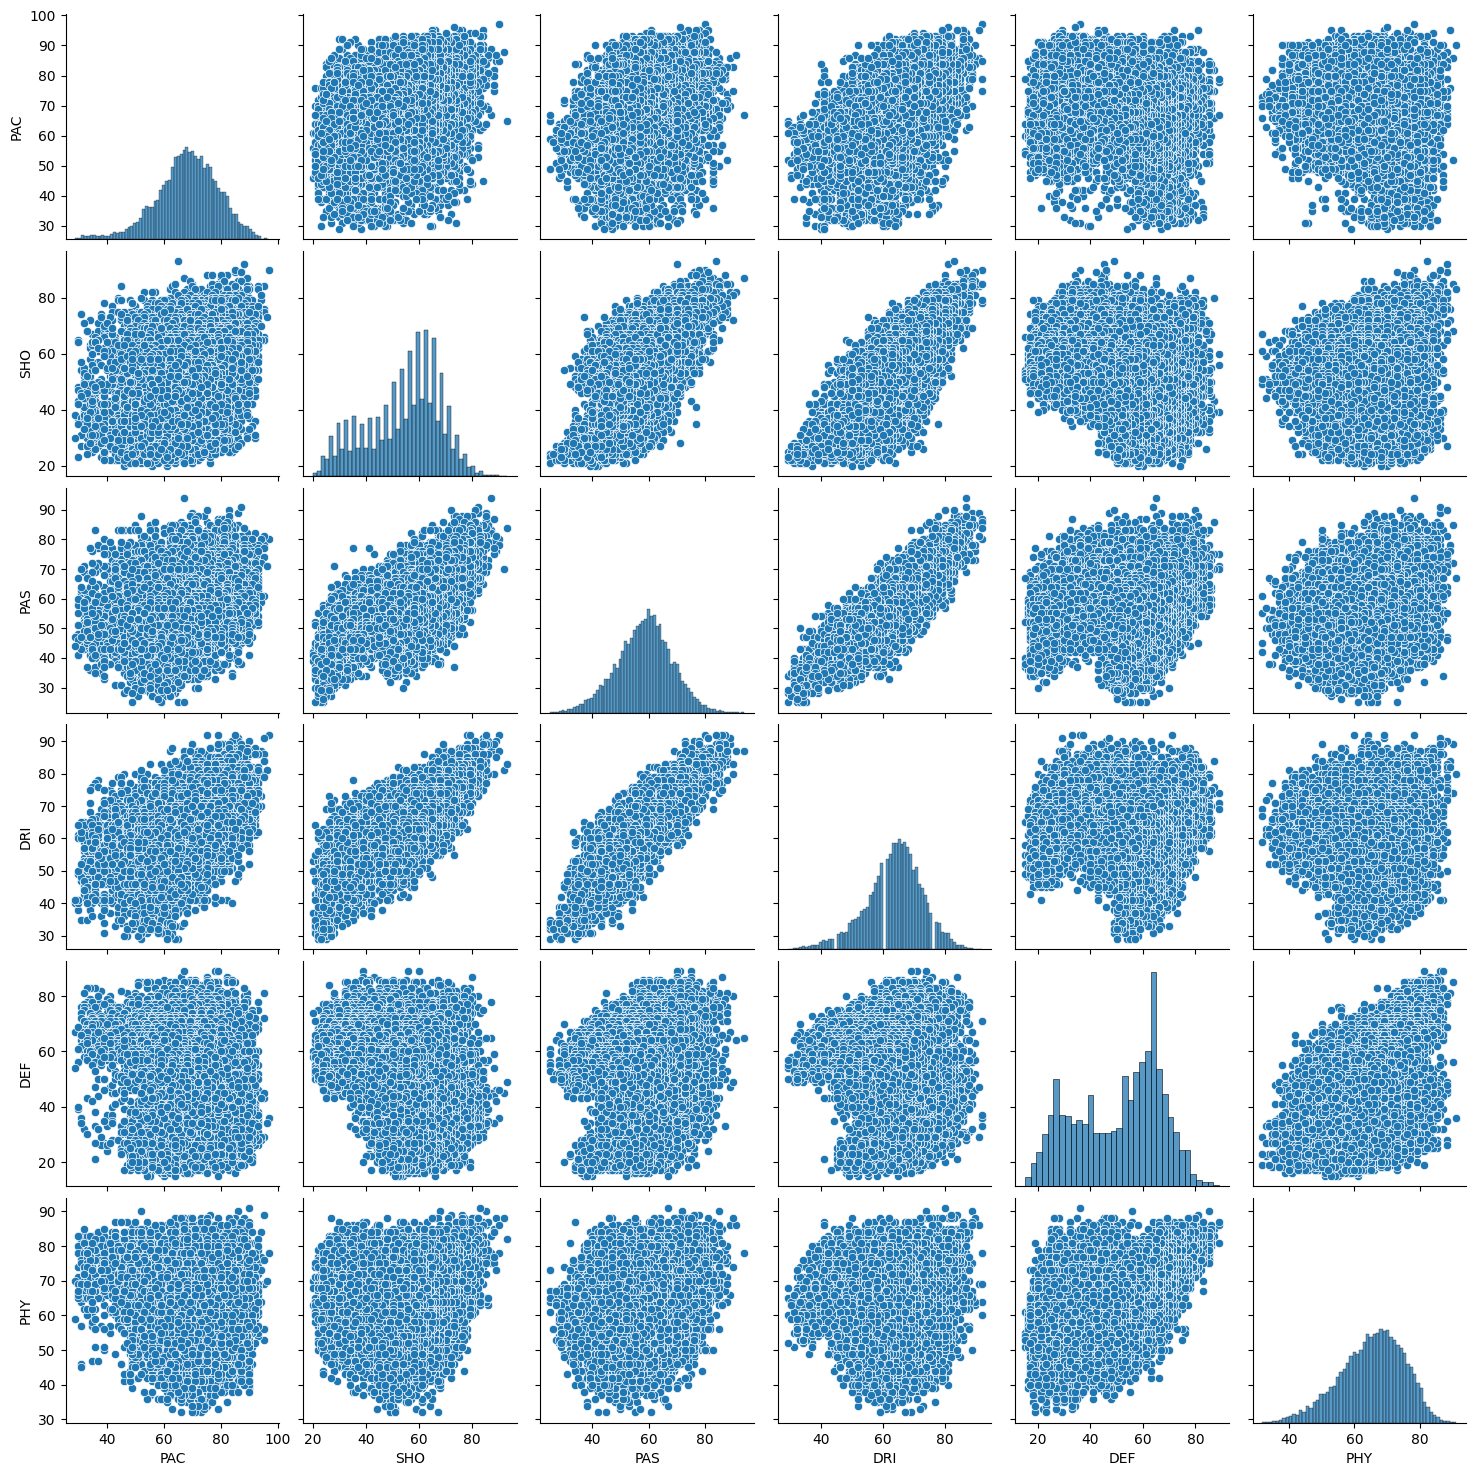

In [ ]:
sns.pairplot(df_jugadores[['PAC','SHO','PAS','DRI','DEF','PHY']])
plt.show()

El análisis exploratorio muesta correlaciones positivas fuertes entre algunas características técnicas: PAS y DRI con 0.85, SHO y DRI con 0.77 y PAS y SHO con 0.68. Esto indica que jugadores con buen dribbling tienden también a destacar en pase y shotting. Estas correlaciones tienen sentido en el contexto del fútbol, donde la calidad técnica suele agrupar estas habilidades.

Se crea un nuevo dataset excluyendo las habilidades generales, ya que estas abarcan a las otras habilidades mas detalladas que se prefieren considerar. Mantenerlas agregaría redundancia.
También se excluyen del dataframe a los arqueros, como asi tambien a los atributos específicos de su rol/posición (reflejos, manejo con las manos, posicionamiento como arquero) ya que no son comparables con los de los jugadores de campo.
Por lo visto en clases, es una posicion que se diferencia claramente de las demas por sus caracteristicas. Y el analisis se centrara en el resto de las posiciones.
También se tendrán en cuenta solo los jugadores con OVR mayor o igual a 70 para trabajar con menos cantidad de muestras.

Para la seleccion de las variables nos respaldamos en la página web https://sofifa.com/ utilizando como referencia el equipo Liverpool (LFC) preteneciente a la Premier League junto con la ayuda de expertos de dominio.

Por lo tanto se considero las habilidades más relevantes según la posición de los jugadores. Haciendo foco en atributos que reflejan cinco grandes categorías: defensa, ataque, creación, velocidad y físico. Así, se incluyeron estadísticas como Interceptions, Standing Tackle y Sliding Tackle para defensa; Finishing y Shot Power para ataque; Vision, Short Passing y Long Passing para creación; Acceleration y Sprint Speed para velocidad; y Strength y Stamina para físico.





In [ ]:
df_aux_field = df_jugadores[(df_jugadores['Position'] != 'GK') &
                            (df_jugadores['OVR']>= 70)].copy()


stats = ['Interceptions', 'Heading Accuracy', 'Standing Tackle',
            'Sliding Tackle', 'Strength', 'Aggression',
            'Vision', 'Short Passing', 'Long Passing',
            'Stamina','Finishing', 'Shot Power',
            'Acceleration', 'Sprint Speed', 'Dribbling', 'Agility', 'Crossing']


df_field = df_aux_field[stats].copy()
df_field.shape

(4297, 17)

In [ ]:
df_field.describe()

,Interceptions,Heading Accuracy,Standing Tackle,Sliding Tackle,Strength,Aggression,Vision,Short Passing,Long Passing,Stamina,Finishing,Shot Power,Acceleration,Sprint Speed,Dribbling,Agility,Crossing
count,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000,4297.000000
mean,58.219921,62.983011,59.498255,56.322318,70.290202,67.575518,65.167791,71.673726,66.022574,73.768676,58.741913,68.022108,70.754014,70.920410,69.651617,70.449383,61.943216
std,19.198774,11.929629,18.963789,19.459016,11.733234,12.210767,11.520608,6.072662,8.941237,9.333916,16.289433,11.195163,12.287173,12.047825,9.929447,12.351532,13.098592
min,11.000000,24.000000,10.000000,10.000000,30.000000,24.000000,22.000000,43.000000,33.000000,31.000000,16.000000,23.000000,29.000000,30.000000,28.000000,29.000000,20.000000
25%,41.000000,55.000000,43.000000,38.000000,63.000000,61.000000,60.000000,68.000000,61.000000,68.000000,48.000000,63.000000,65.000000,65.000000,66.000000,64.000000,55.000000
50%,67.000000,65.000000,68.000000,65.000000,72.000000,70.000000,67.000000,72.000000,67.000000,74.000000,64.000000,70.000000,73.000000,73.000000,72.000000,72.000000,65.000000
75%,72.000000,72.000000,73.000000,71.000000,79.000000,76.000000,73.000000,76.000000,72.000000,80.000000,71.000000,76.000000,79.000000,79.000000,76.000000,79.000000,71.000000
max,89.000000,93.000000,91.000000,88.000000,95.000000,95.000000,95.000000,94.000000,93.000000,95.000000,96.000000,94.000000,97.000000,97.000000,94.000000,95.000000,95.000000


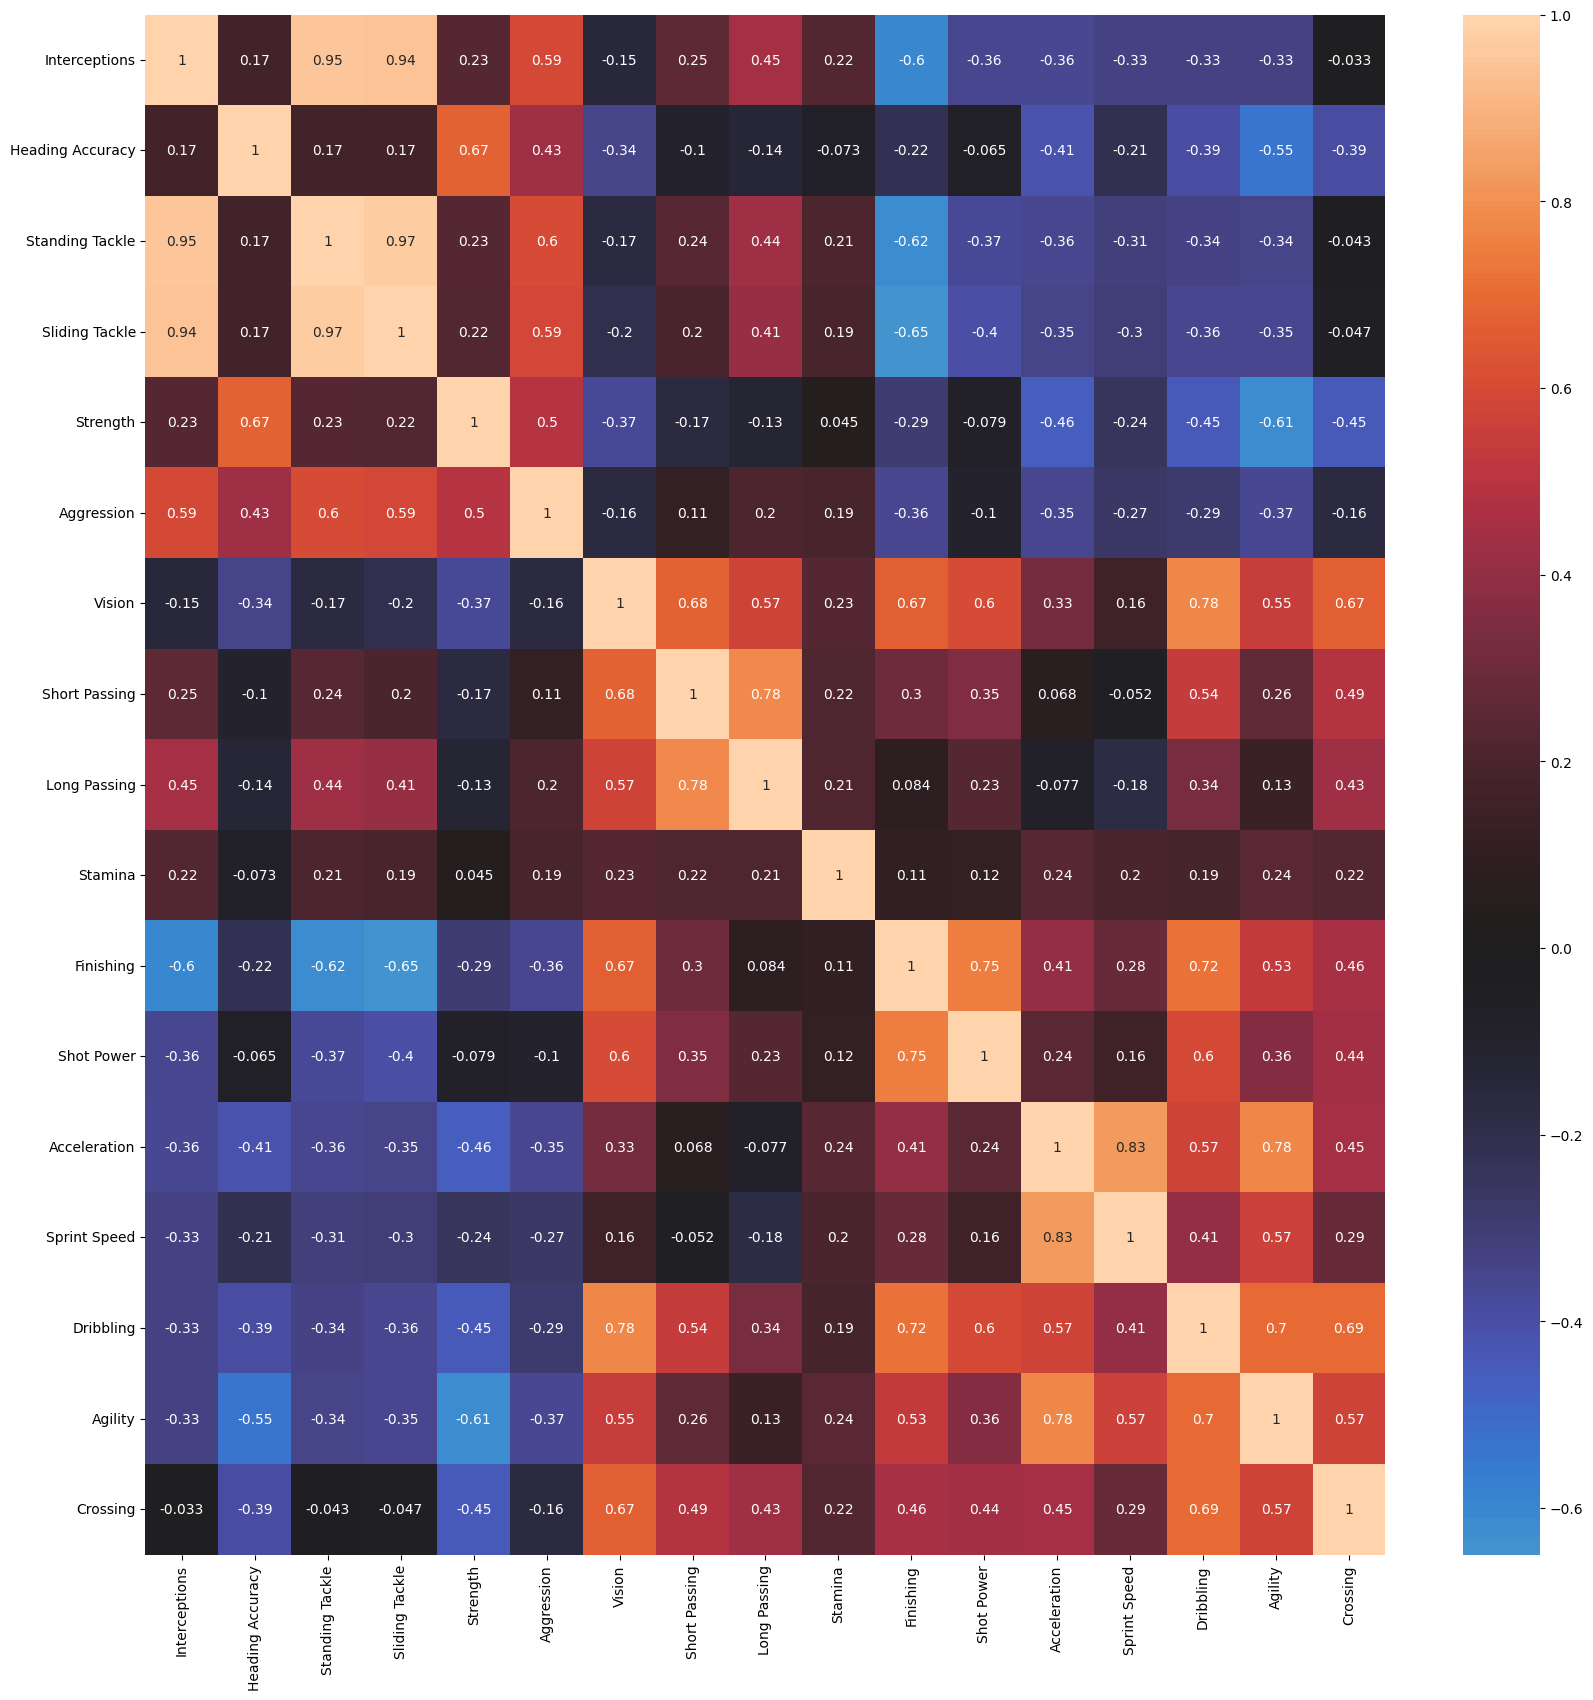

In [ ]:
fig = plt.figure(figsize=(20,20));
sns.heatmap(df_field.corr(), annot=True, center=0)
plt.show()

El mapa de calor de correlaciones nos muestra que hay variables como Sliding Tackle y Interceptions, Sliding Tackle y Standing Tackle, Sprint Speed y Acceleration, entre otras combinaciones, que muestran fuerte correlación. Esta redundancia sugiere que estas variables no aportan información completamente independiente. Por este motivo, más adelante se aplicará PCA para resumir la información contenida en estas variables correlacionadas en menos dimensiones sin perder información (componentes principales).

<br>

----
<br>

Corroboración de presencia de datos nulos para realizar el análisis de componentes principales.

In [ ]:
df_field.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4297 entries, 0 to 4754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Interceptions     4297 non-null   int64
 1   Heading Accuracy  4297 non-null   int64
 2   Standing Tackle   4297 non-null   int64
 3   Sliding Tackle    4297 non-null   int64
 4   Strength          4297 non-null   int64
 5   Aggression        4297 non-null   int64
 6   Vision            4297 non-null   int64
 7   Short Passing     4297 non-null   int64
 8   Long Passing      4297 non-null   int64
 9   Stamina           4297 non-null   int64
 10  Finishing         4297 non-null   int64
 11  Shot Power        4297 non-null   int64
 12  Acceleration      4297 non-null   int64
 13  Sprint Speed      4297 non-null   int64
 14  Dribbling         4297 non-null   int64
 15  Agility           4297 non-null   int64
 16  Crossing          4297 non-null   int64
dtypes: int64(17)
memory usage: 604.3 KB


In [ ]:
df_field.isna().sum()

,0
Interceptions,0
Heading Accuracy,0
Standing Tackle,0
Sliding Tackle,0
Strength,0
Aggression,0
Vision,0
Short Passing,0
Long Passing,0
Stamina,0


Como segundo paso se aplicara un escalado de los datos. Si bien las variables están todas en un rango entre 0 y 99, sus distribuciones y varianzas difieren. Se escalaran los datos para que todas las variables tengan un peso similar al calcular las distancias utilizadas en los métodos de clustering y para asegurar que las técnicas de proyección reflejen correctamente los patrones en los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_field)
df_field_scaled = pd.DataFrame(X_scaled, columns=df_field.columns)
df_field_scaled.shape

(4297, 17)

El siguiente gráfico muestra cuánta información (varianza) se conserva al ir agregando componentes principales:

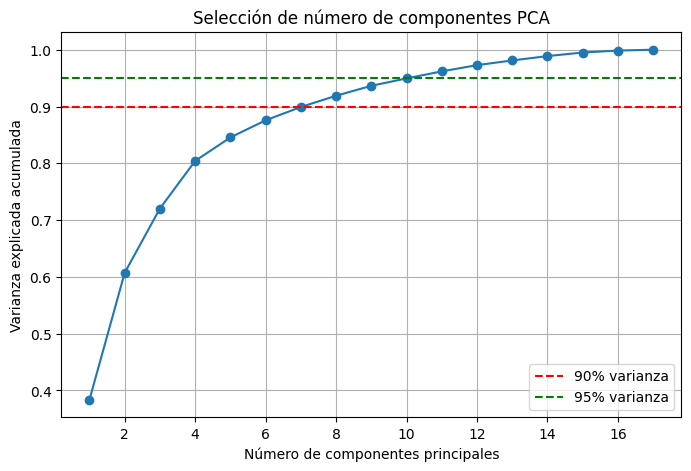

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=17, random_state=42)
X_pca = pca.fit_transform(df_field_scaled)


var_exp = pca.explained_variance_ratio_ #proporción de varianza que explica cada componente.
cum_var_exp = np.cumsum(var_exp) #suma los valores de a uno, para ver la varianza acumulada a medida que se agregan componentes


plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var_exp)+1), cum_var_exp, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('Selección de número de componentes PCA')
plt.legend()
plt.grid(True)
plt.show()

Del gráfico se observa que con 9 componentes principales se logra retener cerca del 95% de la varianza de los datos. Por lo tanto, se optó por trabajar con 9 componentes, ya que permiten reducir la dimensionalidad sin perder información importante.

In [ ]:
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(df_field_scaled)

#### Tecnicas de Clustering

##### K-Means

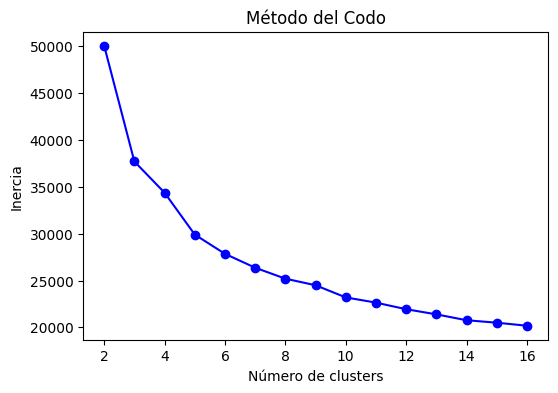

In [ ]:
inertia = []
K = range(2, 17)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'o-', color='blue')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

Como puede observarse, la inercia disminuye significativamente a medida que aumenta el numero de clusters, pero para no caer en un modelo con "over-fitting" seleccionamos una cantidad de clusters entre 5 y 7.

In [ ]:
n_clust = 5

km = KMeans(n_clusters=n_clust, random_state=42,algorithm='lloyd')
clusters = km.fit_predict(X_pca)

Como primera instancia, se utilizaron parametros "default" con el fin de tener un punto de partida para comparar con otros metodos de clustering. Pero cabe aclarar que se utilizó el algoritmo "elkan" sin mejores evidentes.

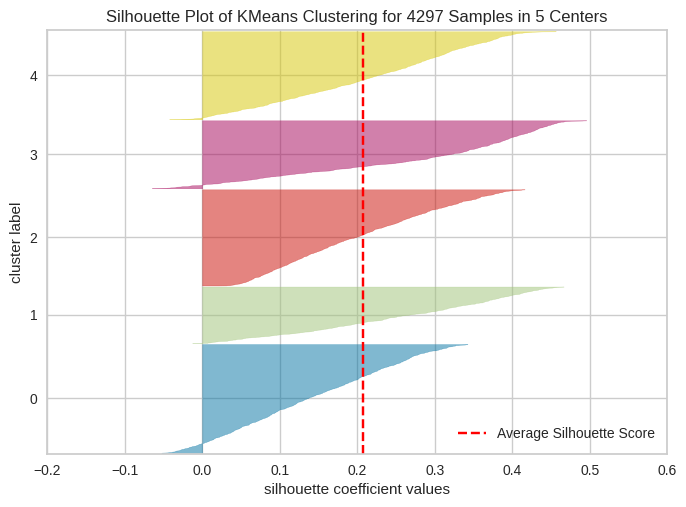

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
visualizer.fit(X_pca)
visualizer.show()
plt.show()

Se puede observar que los clusters no están bien separados, se superponen bastante. Algunos jugadores están mal asignados (los negativos indican que “encajarían mejor” en otro cluster). KMeans quizás no es la mejor opción para este dataset (no todos los datos se adaptan a la idea de clusters esféricos y del mismo tamaño que asume KMeans).

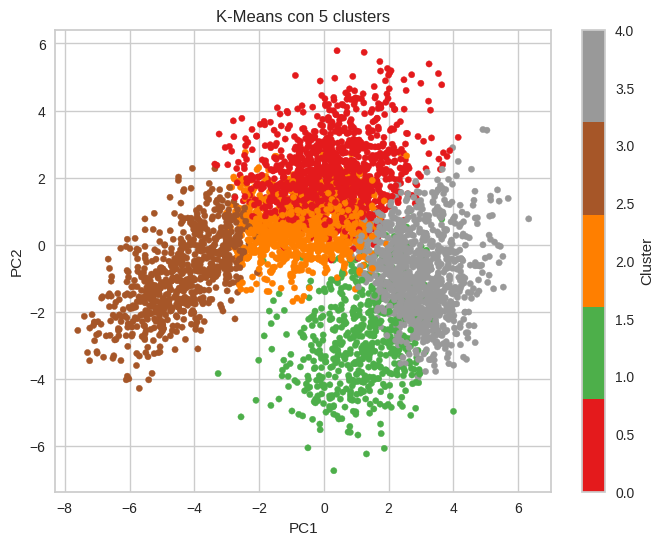

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_pca)


plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=clusters,cmap=plt.cm.get_cmap("Set1", 5), s=20)
plt.title('K-Means con 5 clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.show()

Mediante el uso de un scatter-plot confirmamos que el metodo de K-Means tiene dificultades para poder agrupar ciertas posiciones al notar superposicion entre todos los clusters obtenidos

##### Clusting Jerarquico

* Dendrograma

Debido al resultado anterior, optamos por un metodo de clustering jerarquico. Donde se utilizó el motodo "ward" que minimiza las varianzas intra-cluster, con el fin de lograr agrupaciones mas definidas entre posiciones problemas.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

dm = linkage(X_pca, method='ward', metric='euclidean')


Para visualizar el clustering se recurrio tanto a un dendrograma como tambien al metodo fcluster con 6 agrupaciones

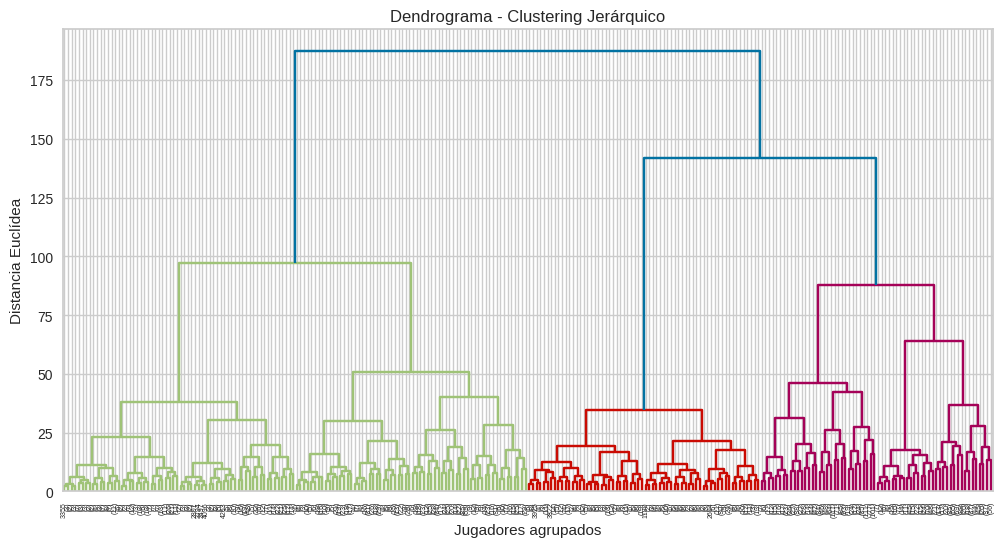

In [ ]:


plt.figure(figsize=(12, 6))
dendrogram(dm, truncate_mode='level', p=7)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Jugadores agrupados')
plt.ylabel('Distancia Euclídea')
plt.show()



In [ ]:

clusters_jer = fcluster(dm, t=6, criterion='maxclust')
df_field['label_posicion'] = clusters_jer

In [ ]:
df_field['label_posicion'].value_counts()


,count
label_posicion,
4,1324
2,1057
6,605
1,547
3,439
5,325


Observamos que los clusters obtenidos no son muy balanceados pero para relacionarlos a los datos originales se utilizará un embedding utilizando TSNE

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2, perplexity=40, n_iter=2000, random_state=42, learning_rate=300)
X_tsne = tsne.fit_transform(X_pca)

In [ ]:
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=df_field.index)
df_tsne['Cluster'] = df_field['label_posicion'].values
df_tsne['Name'] = df_aux_field['Name'].values
df_tsne['Position'] = df_aux_field['Position'].values

In [ ]:
import plotly.io as pio
pio.renderers.default = "colab"


In [ ]:
import plotly.express as px

fig = px.scatter(
    df_tsne,
    x='TSNE1',
    y='TSNE2',
    color='Cluster',
    hover_data=['Name', 'Position', 'Cluster'],
    title='t-SNE de jugadores con posición y cluster'
)
fig.show()

Con clustering jerárquico se puede ver que los jugadores son agrupados por características tecnicas mas que por sus posiciones reales. Los jugadores comparten habilidades y por este motivo sus posicione spueden ser intercambiables.


Esta agrupación tiene sentido dentro del contexto de FIFA, donde las etiquetas posicionales no siempre reflejan el estilo de juego o las capacidades individuales. Por ejemplo, un mediocampista ofensivo muy rápido puede jugar de extremo o delantero en determinadas tácticas, y el algoritmo captura estas habilidades al agruparlos juntos. En consecuencia, los clusters no solo reflejan la posición, sino que identifican tipos de jugadores según su perfil de habilidades, lo que permite un análisis más flexible.

En consecuencia se puede observar, dos clusters, el 2 y 4, que el algoritmo no puede discriminar con la misma definición o presición que el resto de los clusters, esto confirma que el algoritmo no agrupa por posición sino por habilidades técnicas.

#### Impresiones finales

Luego de haber realizado dos metodos de clustering distintos, podemos afirmar que hay cierta cantidad de jugadores cuyas metricas no permiten una separacion mas definida.
Si bien hay posiciones como la de arquero, defensas y ciertos delanteros muy especializados, aquellos jugadores con capacidad de ser mas flexibles tanto en un mediocampo con posibilidad de subir o un delantero que pueda retraerse, generan clusters con un grado de superposicion que no somos capaces de resolver.